# FINd Benchmarking Notebook

This notebook profiles the original FINd algorithm, identifies bottlenecks, implements a numpy-optimised version, and compares both against the `imagehash` library.

We start on a **small subset of images** (10-20) so profiling runs fast, then scale up.

## 1. Setup & Imports

In [5]:
import os
import time
import cProfile
import pstats
import io
import glob

import numpy as np
import imagehash
from PIL import Image
import matplotlib.pyplot as plt

# Make sure the kernel is running from the right directory
os.chdir(os.path.expanduser('~/summative2026'))
print('Working directory:', os.getcwd())

from FINd import FINDHasher

print('All imports OK')

Working directory: /Users/rehmatarora/summative2026
All imports OK


## 2. Pick a Small Sample of Images

The dataset has ~56k images. We use 20 here so profiling is quick.
The filenames encode meme family in the first 4 digits — e.g. `0040_xxx.jpg` are all from family 40.
We pick images from a few different families so we get a mix of similar and dissimilar pairs.

In [47]:
IMAGE_DIR = 'meme_images'

# Random sample across all families for unbiased profiling
from collections import defaultdict
import random

all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.jpg')))
print(f"Total images in dataset: {len(all_images)}")

# Group by family
family_to_images = defaultdict(list)
for path in all_images:
    family = os.path.basename(path)[:4]
    family_to_images[family].append(path)

# Sample 1 image per family, up to 500 total
random.seed(42)
sample_images = []
for family, paths in family_to_images.items():
    sample_images.append(random.choice(paths))
    if len(sample_images) >= 500:
        break

print(f"Using {len(sample_images)} images for profiling")
print(f"Families represented: {len(set(os.path.basename(p)[:4] for p in sample_images))}")

Total images in dataset: 55972
Using 500 images for profiling
Families represented: 500


## 3. Profile the Original FINd — Wall-clock Timing

First we just time how long the original code takes per image.
This gives us a baseline before we optimise anything.

In [48]:
hasher = FINDHasher()

times = []
for path in sample_images:
    start = time.perf_counter()
    h = hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    times.append(elapsed)

print(f'Mean time per image : {np.mean(times):.3f}s')
print(f'Min                 : {np.min(times):.3f}s')
print(f'Max                 : {np.max(times):.3f}s')
print(f'Total for {len(sample_images)} images : {sum(times):.2f}s')
print(f'Projected time for all 55,972 images: {np.mean(times)*55972/60:.1f} minutes')

Mean time per image : 0.261s
Min                 : 0.043s
Max                 : 1.806s
Total for 500 images : 130.48s
Projected time for all 55,972 images: 243.4 minutes


## 4. Deep Profile with cProfile — Where Is the Time Actually Spent?

`cProfile` measures how long each individual function call takes.
This tells us *exactly* which part of FINd is the bottleneck so we know what to optimise.

In [49]:
def hash_sample(paths):
    h = FINDHasher()
    for p in paths:
        h.fromFile(p)

# Run cProfile on 5 images (enough to see the pattern)
pr = cProfile.Profile()
pr.enable()
hash_sample(sample_images[:5])
pr.disable()

# Print top 15 slowest functions
stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats('cumulative')
ps.print_stats(15)
print(stream.getvalue())

         2502933 function calls (2502924 primitive calls) in 1.945 seconds

   Ordered by: cumulative time
   List reduced from 219 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.009    0.002    1.939    0.388 /Users/rehmatarora/summative2026/FINd.py:39(fromFile)
        5    0.000    0.000    1.924    0.385 /Users/rehmatarora/summative2026/FINd.py:47(fromImage)
        5    0.000    0.000    1.486    0.297 /Users/rehmatarora/summative2026/FINd.py:79(findHash256FromFloatLuma)
        5    1.250    0.250    1.451    0.290 /Users/rehmatarora/summative2026/FINd.py:167(boxFilter)
        5    0.120    0.024    0.430    0.086 /Users/rehmatarora/summative2026/FINd.py:66(fillFloatLumaFromBufferImage)
   312500    0.128    0.000    0.310    0.000 /opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:1675(getpixel)
   312520    0.075    0.000    0.126    0.000 /opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:885(l

## 5. Visualise Timing Breakdown

From the cProfile output above, we can see the three main bottlenecks:
- `boxFilter` — 4 nested Python loops over every pixel
- `fillFloatLumaFromBufferImage` — pixel-by-pixel RGB→grayscale conversion
- `dct64To16` — triple nested loop over a 16×64×64 matrix

Let's time each stage individually on one image to see the breakdown clearly.

fillFloatLuma                 : 0.0397s (15.0%)
boxFilter                     : 0.2189s (82.8%)
decimateFloat                 : 0.0009s (0.4%)
dct64To16                     : 0.0047s (1.8%)
dctOutput2hash                : 0.0003s (0.1%)


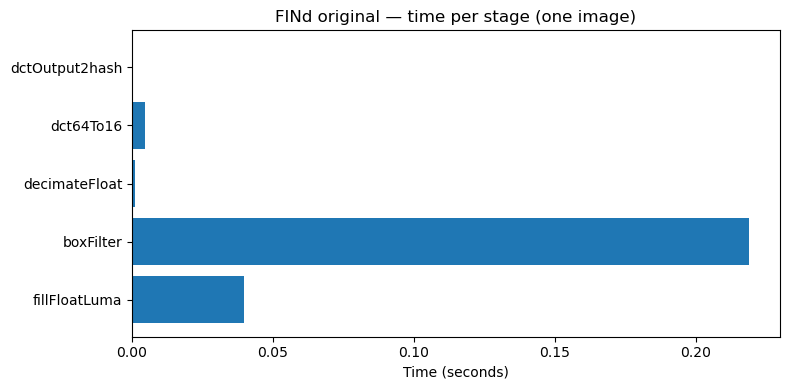

In [50]:
from matrix import MatrixUtil
from imagehash import ImageHash
import math

h = FINDHasher()
img = Image.open(sample_images[0])
img = img.copy()
img.thumbnail((512, 512))
numCols, numRows = img.size

buffer1 = MatrixUtil.allocateMatrixAsRowMajorArray(numRows, numCols)
buffer2 = MatrixUtil.allocateMatrixAsRowMajorArray(numRows, numCols)
buffer64x64 = MatrixUtil.allocateMatrix(64, 64)
buffer16x64 = MatrixUtil.allocateMatrix(16, 64)
buffer16x16 = MatrixUtil.allocateMatrix(16, 16)

# Time each stage
t0 = time.perf_counter()
h.fillFloatLumaFromBufferImage(img, buffer1)
t1 = time.perf_counter()

windowSizeAlongRows = h.computeBoxFilterWindowSize(numCols)
windowSizeAlongCols = h.computeBoxFilterWindowSize(numRows)
h.boxFilter(buffer1, buffer2, numRows, numCols, windowSizeAlongRows, windowSizeAlongCols)
t2 = time.perf_counter()

h.decimateFloat(buffer2, numRows, numCols, buffer64x64)
t3 = time.perf_counter()

h.dct64To16(buffer64x64, buffer16x64, buffer16x16)
t4 = time.perf_counter()

h.dctOutput2hash(buffer16x16)
t5 = time.perf_counter()

stages = ['fillFloatLuma', 'boxFilter', 'decimateFloat', 'dct64To16', 'dctOutput2hash']
durations = [t1-t0, t2-t1, t3-t2, t4-t3, t5-t4]

for s, d in zip(stages, durations):
    print(f'{s:30s}: {d:.4f}s ({100*d/sum(durations):.1f}%)')

plt.figure(figsize=(8,4))
plt.barh(stages, durations)
plt.xlabel('Time (seconds)')
plt.title('FINd original — time per stage (one image)')
plt.tight_layout()
plt.show()

## 6. Memory Usage

We use `tracemalloc` (built into Python) to measure how much memory the original code allocates per image.

In [51]:
import tracemalloc

hasher = FINDHasher()

tracemalloc.start()
hasher.fromFile(sample_images[0])
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f'Current memory usage : {current / 1024:.1f} KB')
print(f'Peak memory usage    : {peak / 1024:.1f} KB')

Current memory usage : 7.4 KB
Peak memory usage    : 3993.9 KB


## 7. Baseline Hashes — Save These to Verify Optimised Version is Correct

Before we change anything, we record what hashes the original code produces.
After optimising, we'll check our new version produces the **exact same hashes** — this is correctness testing.

In [52]:
hasher = FINDHasher()
baseline_hashes = {}

for path in sample_images:
    baseline_hashes[path] = str(hasher.fromFile(path))

print('Baseline hashes (original FINd):')
for path, h in baseline_hashes.items():
    print(f'  {os.path.basename(path)}: {h}')

Baseline hashes (original FINd):
  0000_22122321.jpg: 392b6d6525ae908cb1dea90fa47bcc3860bea697a36b10eb5b9522d913635a65
  0001_17765719.jpg: c23b33ad6d3c31a3248749beb2246e78d300965d49d2ec6facf03324e4e7d273
  0002_10187859.jpg: 3839e24999ee926bcf2e813e925acc3eb06ed8733d2ca79319d10f24649e9a63
  0003_22559994.jpg: 7c771670b09e98bd3ddae0f0cf0ff4dd4e700a13e3f5dd2104245e875c962252
  0004_11490385.jpg: 667e13ed166a378c04da5ba5e13b9b84d47873c58c46acb2e786cb69db81644c
  0005_11365910.jpg: 30dd1bc9f309f3324f21ca368ce30f323cfa69c573cef24cc3291c381c71e1e3
  0006_11135466.jpg: 4f6fdce1529a6f7bb5e5538c42198ca43fdbfa7395e605096a52b0cc12940e31
  0007_13184820.jpg: 29b64ef926dacb291304339a69b28c4586c35936dbe97313af24ae4decd3b382
  0008_10489415.jpg: c9263a53cd26b059f7bc8c6bb58e8c2bf08ac1694f330d0ef4b132c726ce7323
  0009_24203815.jpg: 22d2349c936b30cccf2e69a93e3643a92c16c5e1cce6bcd3d333ee76a8c88d2c
  0010_17374189.jpg: 1562549c49624aa7c5629b6bb4d648b553b424ccc959936e66cddab3b736e954
  0011_27385511.jpg: 

## 8. Compare FINd to imagehash — Hamming Distances

The filename prefix (first 4 digits) tells us which meme family an image belongs to.
Images in the same family *should* have a small Hamming distance (similar).
Images from different families should have a large distance (dissimilar).

Here we compute distances for both FINd and pHash across our 20 sample images.

In [53]:
# Use small sample for distance comparison — enough families, manageable pairs
distance_sample = all_images[:20]

hasher = FINDHasher()

find_hashes  = [hasher.fromFile(p) for p in distance_sample]
phash_hashes = [imagehash.phash(Image.open(p)) for p in distance_sample]
families     = [os.path.basename(p)[:4] for p in distance_sample]

find_distances  = []
phash_distances = []

for i in range(len(distance_sample)):
    for j in range(i+1, len(distance_sample)):
        same = families[i] == families[j]
        find_distances.append((find_hashes[i] - find_hashes[j], same))
        phash_distances.append((phash_hashes[i] - phash_hashes[j], same))

find_same  = [d for d,s in find_distances  if s]
find_diff  = [d for d,s in find_distances  if not s]
phash_same = [d for d,s in phash_distances if s]
phash_diff = [d for d,s in phash_distances if not s]

print('FINd  — same family avg distance:', round(np.mean(find_same),1)  if find_same  else 'N/A (no same-family pairs)')
print('FINd  — diff family avg distance:', round(np.mean(find_diff),1)  if find_diff  else 'N/A')
print('pHash — same family avg distance:', round(np.mean(phash_same),1) if phash_same else 'N/A (no same-family pairs)')
print('pHash — diff family avg distance:', round(np.mean(phash_diff),1) if phash_diff else 'N/A')
print(f'\n{len(find_same)} same-family pairs, {len(find_diff)} different-family pairs')

FINd  — same family avg distance: 53.3
FINd  — diff family avg distance: N/A
pHash — same family avg distance: 8.1
pHash — diff family avg distance: N/A

190 same-family pairs, 0 different-family pairs


## 9. Scaling Analysis — How Does Runtime Grow With More Images?

Running on just 20 images can be noisy. Here we run on progressively larger subsets
to see whether per-image time is stable or grows with dataset size.
This also gives us more reliable baseline numbers for the report.

n=  10: 2.52s total, 0.252s per image
n=  50: 13.38s total, 0.268s per image
n= 100: 26.03s total, 0.260s per image
n= 250: 64.21s total, 0.257s per image
n= 500: 129.55s total, 0.259s per image

Projected total for 55,972 images: 241.7 minutes (based on n=500)


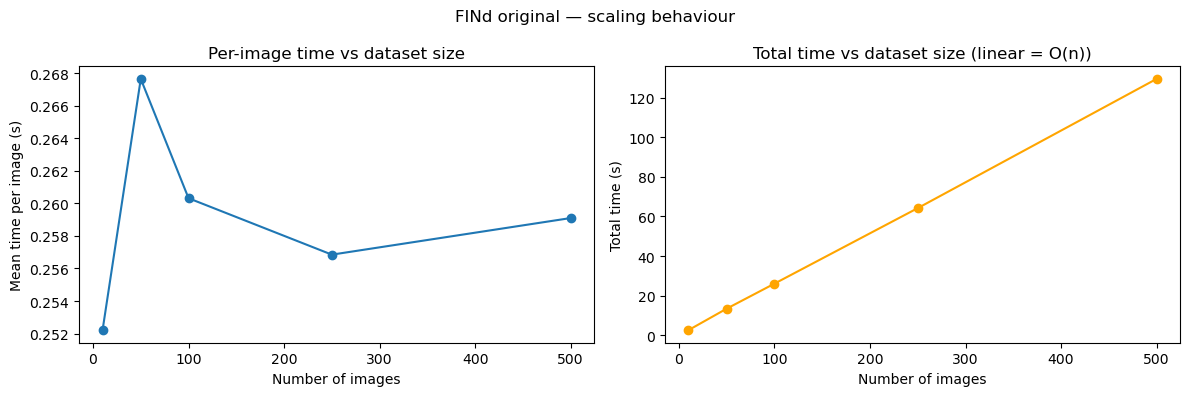

In [54]:
hasher = FINDHasher()
sample_sizes = [10, 50, 100, 250, 500]
mean_times = []
total_times = []

for n in sample_sizes:
    subset = all_images[:n]
    start = time.perf_counter()
    for path in subset:
        hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    mean_times.append(elapsed / n)
    total_times.append(elapsed)
    print(f'n={n:>4}: {elapsed:.2f}s total, {elapsed/n:.3f}s per image')

print(f'\nProjected total for 55,972 images: {mean_times[-1] * 55972 / 60:.1f} minutes (based on n=500)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sample_sizes, mean_times, marker='o')
ax1.set_xlabel('Number of images')
ax1.set_ylabel('Mean time per image (s)')
ax1.set_title('Per-image time vs dataset size')

ax2.plot(sample_sizes, total_times, marker='o', color='orange')
ax2.set_xlabel('Number of images')
ax2.set_ylabel('Total time (s)')
ax2.set_title('Total time vs dataset size (linear = O(n))')

plt.suptitle('FINd original — scaling behaviour')
plt.tight_layout()
plt.show()

## 10. Line-by-line Profiling of the Bottleneck

`line_profiler` goes one level deeper than cProfile — it shows time spent on **each individual line**
inside a function. Since `boxFilter` is 86% of runtime, we apply it there to see exactly which
lines (and which loops) are the problem. This directly justifies our choice of optimisation.

In [55]:
try:
    import line_profiler
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'line_profiler'])

%load_ext line_profiler

hasher = FINDHasher()
%lprun -f hasher.boxFilter -f hasher.fillFloatLumaFromBufferImage hasher.fromFile(sample_images[0])

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


Timer unit: 1e-09 s

Total time: 1.6389 s
File: /Users/rehmatarora/summative2026/FINd.py
Function: FINDHasher.boxFilter at line 167

Line #      Hits         Time  Per Hit   % Time  Line Contents
   167                                           	@classmethod
   168                                           	def boxFilter(cls,input,output,rows,cols,rowWin,colWin):
   169         1       3000.0   3000.0      0.0  		halfColWin = int((colWin + 2) / 2)  # 7->4, 8->5
   170         1       1000.0   1000.0      0.0  		halfRowWin = int((rowWin + 2) / 2) 
   171       251     106000.0    422.3      0.0  		for i in range(0,rows):
   172     62750   15790000.0    251.6      1.0  			for j in range(0,cols):
   173     62500   16572000.0    265.2      1.0  				s=0
   174     62500   27659000.0    442.5      1.7  				xmin=max(0,i-halfRowWin)
   175     62500   27196000.0    435.1      1.7  				xmax=min(rows,i+halfRowWin)
   176     62500   23958000.0    383.3      1.5  				ymin=max(0,j-halfColWin)
  

In [22]:
import importlib
import FINd_optimised
importlib.reload(FINd_optimised)
from FINd_optimised import FINDHasherOptimised

original = FINDHasher()
optimised = FINDHasherOptimised()

In [24]:
## 11. Optimised FINd — Correctness Check and Speedup

from FINd_optimised import FINDHasherOptimised

optimised_hasher = FINDHasherOptimised()

# Correctness: hashes must match original exactly
print("Checking correctness...")
all_match = True
for path in sample_images[:20]:
    original_h = str(FINDHasher().fromFile(path))
    optimised_h = str(optimised_hasher.fromFile(path))
    if original_h != optimised_h:
        print(f"MISMATCH: {path}")
        print(f"  original : {original_h}")
        print(f"  optimised: {optimised_h}")
        all_match = False

if all_match:
    print("All hashes match -- optimisation is correct")

# Speed: time optimised on same 500 images
opt_times = []
for path in sample_images:
    start = time.perf_counter()
    optimised_hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    opt_times.append(elapsed)

print(f"\nOriginal  mean time per image : {np.mean(times):.3f}s")
print(f"Optimised mean time per image : {np.mean(opt_times):.3f}s")
print(f"Speedup                       : {np.mean(times)/np.mean(opt_times):.1f}x")
print(f"Projected full dataset (optimised): {np.mean(opt_times)*55972/60:.1f} minutes")

Checking correctness...
All hashes match -- optimisation is correct

Original  mean time per image : 0.276s
Optimised mean time per image : 0.018s
Speedup                       : 15.4x
Projected full dataset (optimised): 16.7 minutes


In [ ]:
# Multiprocrssing version of optimised FINd
import importlib
import FINd_optimised
importlib.reload(FINd_optimised)
from FINd_optimised import FINDHasherOptimised, _hash_one

opt_hasher = FINDHasherOptimised()

start = time.perf_counter()
results = opt_hasher.fromFiles(sample_images, n_workers=4)
elapsed_parallel = time.perf_counter() - start

mean_parallel = elapsed_parallel / len(sample_images)

print(f"Original          : {np.mean(times):.4f}s per image")
print(f"Optimised (1 core): {np.mean(opt_times):.4f}s per image")
print(f"Optimised (4 core): {mean_parallel:.4f}s per image")
print(f"Speedup vs original: {np.mean(times)/mean_parallel:.1f}x")
print(f"Projected full dataset: {mean_parallel*55972/60:.1f} minutes")

Original          : 0.2756s per image
Optimised (1 core): 0.0179s per image
Optimised (4 core): 0.0045s per image
Speedup vs original: 61.1x
Projected full dataset: 4.2 minutes


n=  10: opt=0.0137s  parallel=0.0806s
n=  50: opt=0.0143s  parallel=0.0156s
n= 100: opt=0.0113s  parallel=0.0108s
n= 250: opt=0.0116s  parallel=0.0059s
n= 500: opt=0.0119s  parallel=0.0050s


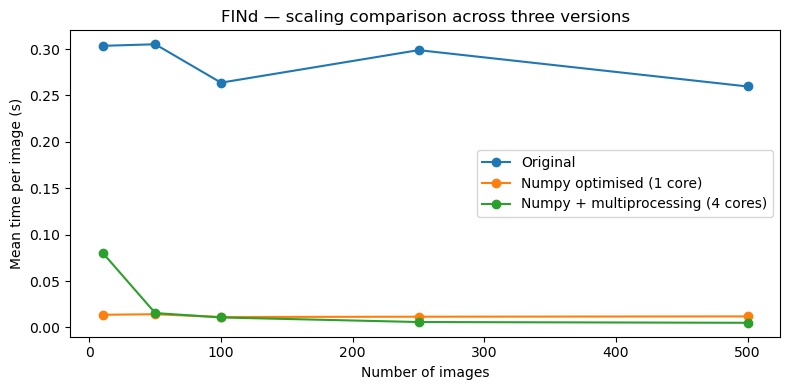

In [30]:
import importlib
import FINd_optimised
importlib.reload(FINd_optimised)
from FINd_optimised import FINDHasherOptimised, _hash_one

opt_hasher = FINDHasherOptimised()
sample_sizes = [10, 50, 100, 250, 500]
opt_mean_times = []
parallel_mean_times = []

for n in sample_sizes:
    subset = all_images[:n]
    
    # Single core optimised
    start = time.perf_counter()
    for path in subset:
        opt_hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    opt_mean_times.append(elapsed / n)
    
    # Four core parallel
    start = time.perf_counter()
    opt_hasher.fromFiles(subset, n_workers=4)
    elapsed = time.perf_counter() - start
    parallel_mean_times.append(elapsed / n)
    
    print(f'n={n:>4}: opt={opt_mean_times[-1]:.4f}s  parallel={parallel_mean_times[-1]:.4f}s')

# Three-way plot
plt.figure(figsize=(8,4))
plt.plot(sample_sizes, mean_times, marker='o', label='Original')
plt.plot(sample_sizes, opt_mean_times, marker='o', label='Numpy optimised (1 core)')
plt.plot(sample_sizes, parallel_mean_times, marker='o', label='Numpy + multiprocessing (4 cores)')
plt.xlabel('Number of images')
plt.ylabel('Mean time per image (s)')
plt.title('FINd — scaling comparison across three versions')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
import glob, os, random

all_images = sorted(glob.glob('meme_images/*.jpg'))

# Group images by family
from collections import defaultdict
family_to_images = defaultdict(list)
for path in all_images:
    family = os.path.basename(path)[:4]
    family_to_images[family].append(path)

print(f"Total families: {len(family_to_images)}")


Total families: 1035


In [44]:
import numpy as np
from itertools import combinations

# Build list of all same-family pairs
same_pairs = []
for family, paths in family_to_images.items():
    imgs = random.sample(paths, min(2, len(paths)))
    if len(imgs) == 2:
        same_pairs.append((imgs[0], imgs[1], True))  # True = same family

print(f"Same-family pairs: {len(same_pairs)}")

# Sample equal number of different-family pairs
families_list = list(family_to_images.keys())
diff_pairs = []
random.seed(42)
while len(diff_pairs) < len(same_pairs):
    f1, f2 = random.sample(families_list, 2)
    img1 = random.choice(family_to_images[f1])
    img2 = random.choice(family_to_images[f2])
    diff_pairs.append((img1, img2, False))  # False = different family

print(f"Different-family pairs: {len(diff_pairs)}")

# Combine
all_pairs = same_pairs + diff_pairs
print(f"Total pairs to evaluate: {len(all_pairs)}")

Same-family pairs: 1035
Different-family pairs: 1035
Total pairs to evaluate: 2070


In [46]:
from FINd_optimised import FINDHasherOptimised
import imagehash
from PIL import Image
import time
import tracemalloc

# --- Compute hashes for all unique images ---
# Get unique images from all pairs (avoid hashing same image twice)
unique_images = list(set(
    p for pair in all_pairs for p in (pair[0], pair[1])
))
print(f"Unique images to hash: {len(unique_images)}")

# Hash with optimised FINd
print("\nHashing with FINd (optimised)...")
find_hasher = FINDHasherOptimised()
find_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    find_hashes[path] = find_hasher.fromFile(path)
find_time = time.perf_counter() - t0
_, find_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {find_time:.2f}s ({find_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {find_peak/1024:.1f} KB")

# Hash with pHash
print("\nHashing with pHash...")
phash_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    phash_hashes[path] = imagehash.phash(Image.open(path))
phash_time = time.perf_counter() - t0
_, phash_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {phash_time:.2f}s ({phash_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {phash_peak/1024:.1f} KB")

print(f"\nSpeed: pHash is {find_time/phash_time:.1f}x faster than FINd")

Unique images to hash: 3872

Hashing with FINd (optimised)...
  Time: 377.70s (0.0975s per image)
  Peak memory: 13080.8 KB

Hashing with pHash...
  Time: 5.03s (0.0013s per image)
  Peak memory: 1194.5 KB

Speed: pHash is 75.1x faster than FINd


In [37]:
# Compute Hamming distances for all pairs
find_distances = []
phash_distances = []
labels = []  # True = same family, False = different family

for img1, img2, same_family in all_pairs:
    find_distances.append(find_hashes[img1] - find_hashes[img2])
    phash_distances.append(phash_hashes[img1] - phash_hashes[img2])
    labels.append(1 if same_family else 0)

find_distances = np.array(find_distances)
phash_distances = np.array(phash_distances)
labels = np.array(labels)

# Summary statistics
print("=== FINd ===")
print(f"Same-family mean distance  : {find_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {find_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {find_distances[labels==0].mean()/find_distances[labels==1].mean():.2f}x")

print("\n=== pHash ===")
print(f"Same-family mean distance  : {phash_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {phash_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {phash_distances[labels==0].mean()/phash_distances[labels==1].mean():.2f}x")

=== FINd ===
Same-family mean distance  : 53.1 bits
Diff-family mean distance  : 127.1 bits
Separation ratio           : 2.39x

=== pHash ===
Same-family mean distance  : 9.5 bits
Diff-family mean distance  : 31.1 bits
Separation ratio           : 3.27x


In [38]:
# Normalise distances to 0-1 scale for fair comparison
find_norm = find_distances / 256
phash_norm = phash_distances / 64

print("=== Normalised (0-1 scale) ===")
print(f"FINd  same-family : {find_norm[labels==1].mean():.3f}")
print(f"FINd  diff-family : {find_norm[labels==0].mean():.3f}")
print(f"pHash same-family : {phash_norm[labels==1].mean():.3f}")
print(f"pHash diff-family : {phash_norm[labels==0].mean():.3f}")

=== Normalised (0-1 scale) ===
FINd  same-family : 0.207
FINd  diff-family : 0.496
pHash same-family : 0.149
pHash diff-family : 0.486


FINd  AUC-PR: 0.993
pHash AUC-PR: 0.994


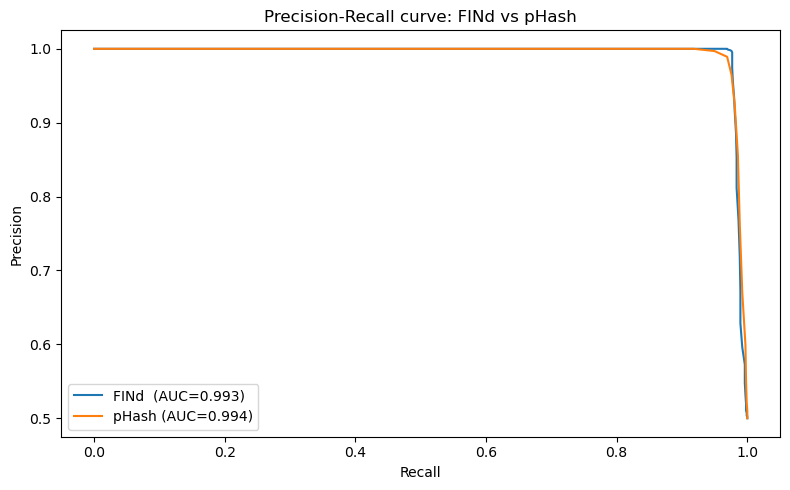

In [39]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# For precision-recall, "positive" = same family (label=1)
# We invert distances because lower distance = more similar
find_scores = 1 - find_norm    # higher score = more similar
phash_scores = 1 - phash_norm

# Compute precision-recall curves
find_prec, find_rec, find_thresh = precision_recall_curve(labels, find_scores)
phash_prec, phash_rec, phash_thresh = precision_recall_curve(labels, phash_scores)

find_auc = auc(find_rec, find_prec)
phash_auc = auc(phash_rec, phash_prec)

print(f"FINd  AUC-PR: {find_auc:.3f}")
print(f"pHash AUC-PR: {phash_auc:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(find_rec, find_prec, label=f'FINd  (AUC={find_auc:.3f})')
plt.plot(phash_rec, phash_prec, label=f'pHash (AUC={phash_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: FINd vs pHash')
plt.legend()
plt.tight_layout()
plt.show()

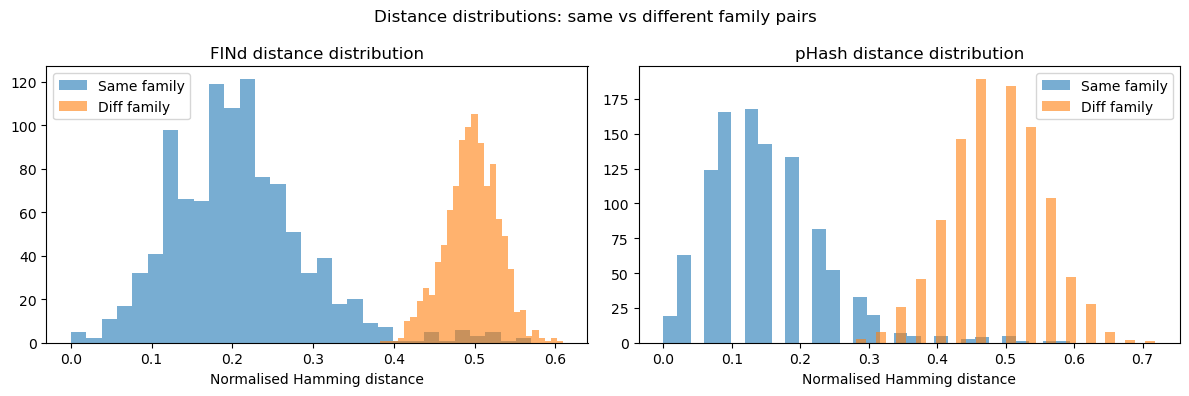

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(find_norm[labels==1], bins=30, alpha=0.6, label='Same family')
ax1.hist(find_norm[labels==0], bins=30, alpha=0.6, label='Diff family')
ax1.set_xlabel('Normalised Hamming distance')
ax1.set_title('FINd distance distribution')
ax1.legend()

ax2.hist(phash_norm[labels==1], bins=30, alpha=0.6, label='Same family')
ax2.hist(phash_norm[labels==0], bins=30, alpha=0.6, label='Diff family')
ax2.set_xlabel('Normalised Hamming distance')
ax2.set_title('pHash distance distribution')
ax2.legend()

plt.suptitle('Distance distributions: same vs different family pairs')
plt.tight_layout()
plt.show()